--- Loading database from vector_db.pkl ---
📊 Processing 12614 chunks for PCA Visualization...
✅ Plotting complete. Opening window...


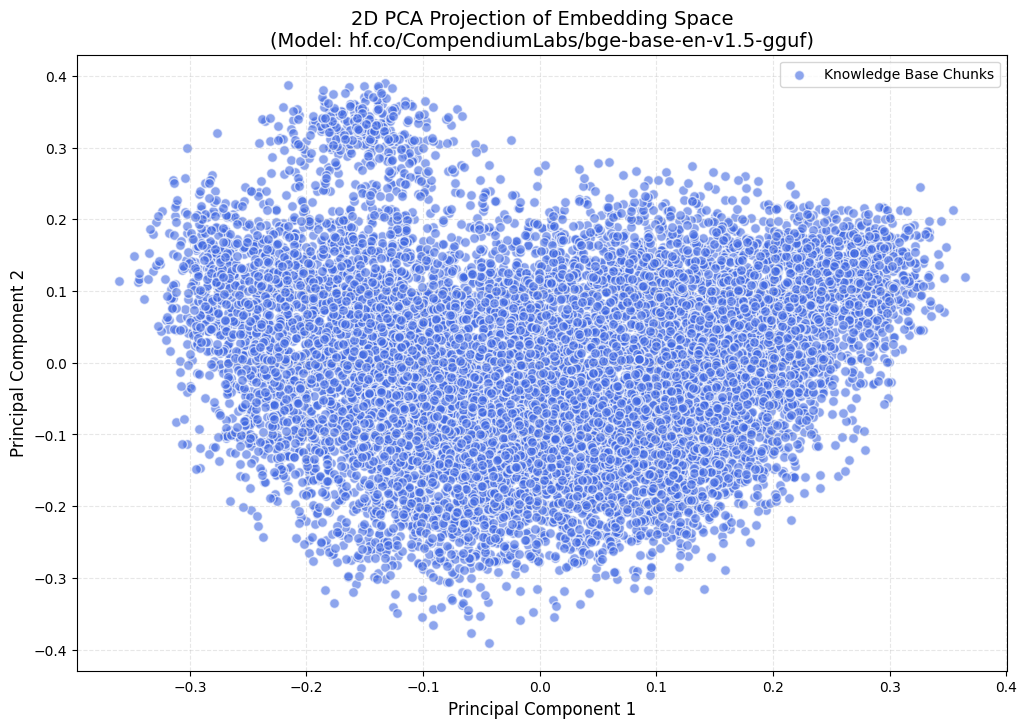

In [2]:
import ollama
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- CONFIGURATION ---
DB_FILE = 'vector_db.pkl'
EMBEDDING_MODEL = 'hf.co/CompendiumLabs/bge-base-en-v1.5-gguf'

def visualize_embeddings(vector_db):
    if not vector_db:
        print("❌ Error: VECTOR_DB is empty. Run the ingestion part first.")
        return

    print(f"📊 Processing {len(vector_db)} chunks for PCA Visualization...")
    
    # 1. Extract all embeddings from the DB
    # We convert to a NumPy array for faster processing
    embeddings = np.array([item['embedding'] for item in vector_db])
    
    # 2. PCA Reduction to 2D
    # PCA finds the two axes that represent the most variance in your data
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(embeddings)
    
    # 3. Plotting
    plt.figure(figsize=(12, 8))
    
    # Create the scatter plot
    plt.scatter(
        reduced_data[:, 0], 
        reduced_data[:, 1], 
        alpha=0.6, 
        c='royalblue', 
        edgecolors='w', 
        s=50,
        label='Knowledge Base Chunks'
    )
    
    plt.title(f"2D PCA Projection of Embedding Space\n(Model: {EMBEDDING_MODEL})", fontsize=14)
    plt.xlabel("Principal Component 1", fontsize=12)
    plt.ylabel("Principal Component 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()
    
    print("✅ Plotting complete. Opening window...")
    plt.show()

# --- EXECUTION ---
if os.path.exists(DB_FILE):
    print(f"--- Loading database from {DB_FILE} ---")
    with open(DB_FILE, 'rb') as f:
        VECTOR_DB = pickle.load(f)
    
    # Proceed directly to visualization
    visualize_embeddings(VECTOR_DB)
else:
    print(f"❌ Error: {DB_FILE} not found. Please run your ingestion script first to create the embeddings.")

🧬 Running t-SNE on 12614 chunks...
✅ Done! If the dots are grouped by color, your document has a clear topical flow.


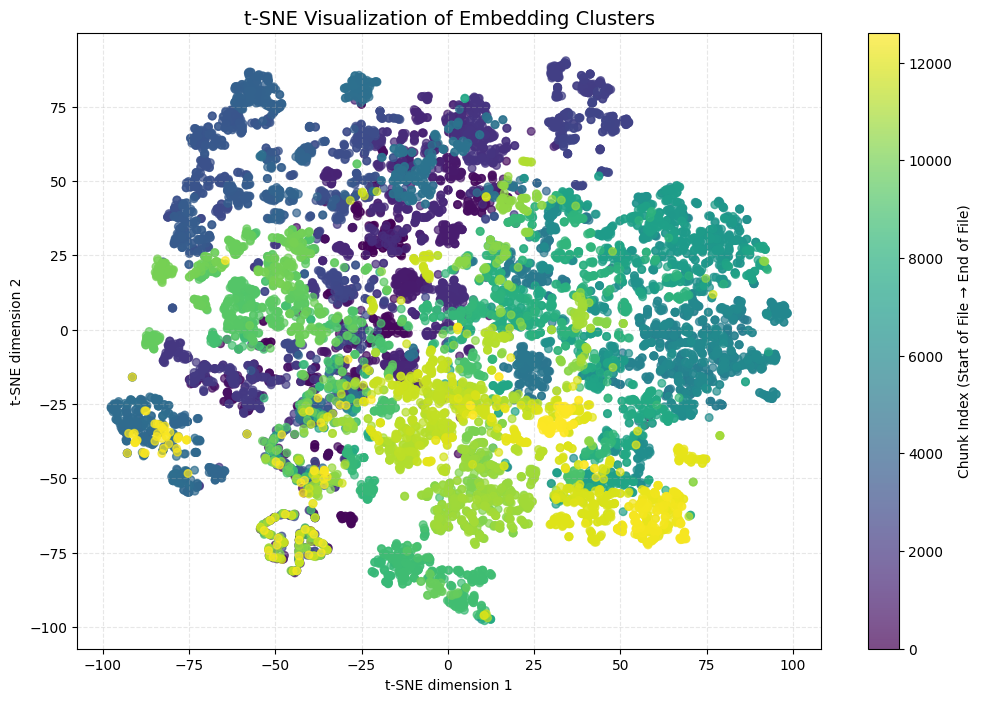

In [3]:
import ollama
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE # Changed from PCA

# --- CONFIGURATION ---
DB_FILE = 'vector_db.pkl'

def visualize_with_tsne(vector_db):
    if not vector_db:
        print("❌ Error: VECTOR_DB is empty.")
        return

    print(f"🧬 Running t-SNE on {len(vector_db)} chunks...")
    
    # 1. Extract embeddings and indices for coloring
    embeddings = np.array([item['embedding'] for item in vector_db])
    indices = np.arange(len(vector_db)) # Used for the color gradient
    
    # 2. t-SNE Reduction
    # perplexity: roughly the number of neighbors each point considers
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    reduced_data = tsne.fit_transform(embeddings)
    
    # 3. Plotting
    plt.figure(figsize=(12, 8))
    
    # We use a colormap (cmap) to see the document progression
    scatter = plt.scatter(
        reduced_data[:, 0], 
        reduced_data[:, 1], 
        c=indices, 
        cmap='viridis', 
        alpha=0.7, 
        s=30
    )
    
    # Add a colorbar to show start vs end of file
    cbar = plt.colorbar(scatter)
    cbar.set_label('Chunk Index (Start of File → End of File)')
    
    plt.title("t-SNE Visualization of Embedding Clusters", fontsize=14)
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    
    print("✅ Done! If the dots are grouped by color, your document has a clear topical flow.")
    plt.show()

# --- EXECUTION ---
if os.path.exists(DB_FILE):
    with open(DB_FILE, 'rb') as f:
        VECTOR_DB = pickle.load(f)
    visualize_with_tsne(VECTOR_DB)

🧊 Generating 3D PCA for 12614 chunks...
✅ 3D Plot generated. You can now rotate the view in the popup window.


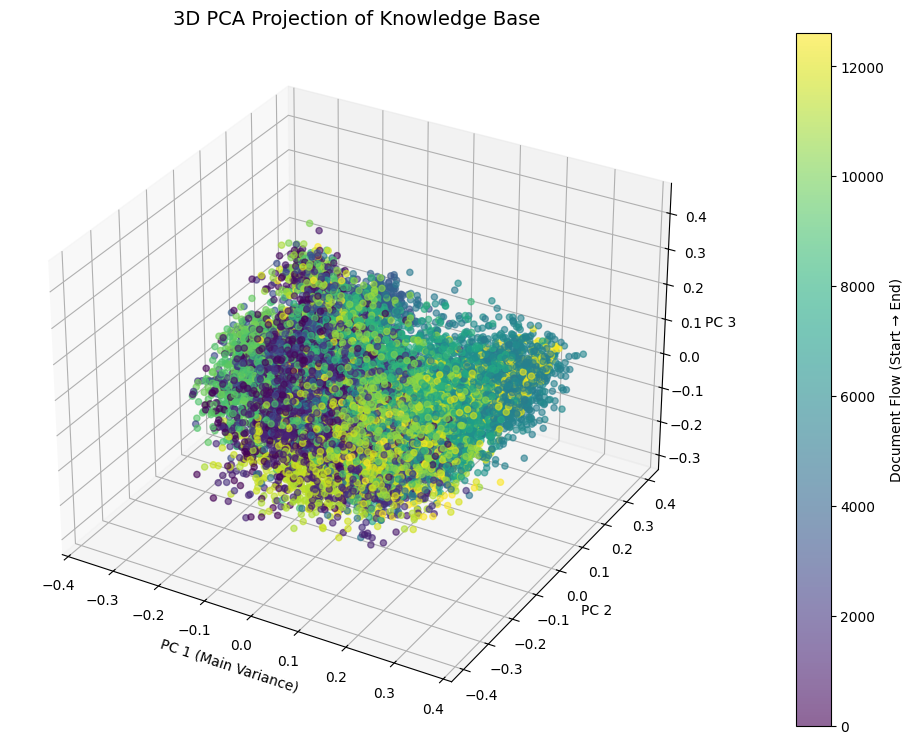

In [4]:
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection

# --- CONFIGURATION ---
DB_FILE = 'vector_db.pkl'

def visualize_3d_pca(vector_db):
    if not vector_db:
        print("❌ Error: VECTOR_DB is empty.")
        return

    print(f"🧊 Generating 3D PCA for {len(vector_db)} chunks...")
    
    # 1. Extract embeddings and indices
    embeddings = np.array([item['embedding'] for item in vector_db])
    indices = np.arange(len(vector_db))
    
    # 2. PCA Reduction to 3D
    pca = PCA(n_components=3)
    reduced_data = pca.fit_transform(embeddings)
    
    # 3. Plotting
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create the 3D scatter plot
    # We use the same color gradient as the t-SNE for consistency
    scatter = ax.scatter(
        reduced_data[:, 0], 
        reduced_data[:, 1], 
        reduced_data[:, 2], 
        c=indices, 
        cmap='viridis', 
        alpha=0.6, 
        s=20
    )
    
    # Add labels and styling
    ax.set_title("3D PCA Projection of Knowledge Base", fontsize=14)
    ax.set_xlabel("PC 1 (Main Variance)")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
    cbar.set_label('Document Flow (Start → End)')
    
    print("✅ 3D Plot generated. You can now rotate the view in the popup window.")
    plt.show()

# --- EXECUTION ---
if os.path.exists(DB_FILE):
    with open(DB_FILE, 'rb') as f:
        VECTOR_DB = pickle.load(f)
    visualize_3d_pca(VECTOR_DB)
else:
    print(f"❌ Error: {DB_FILE} not found.")

In [12]:
import numpy as np
import faiss
import ollama
import pickle
import time
from sklearn.cluster import KMeans

# --- CONFIGURATION ---
DB_FILE = 'vector_db_oran_all.pkl'
EMBEDDING_MODEL = 'hf.co/CompendiumLabs/bge-base-en-v1.5-gguf'
GENERATION_MODEL = 'hf.co/bartowski/Llama-3.2-1B-Instruct-GGUF' 
N_CLUSTERS = 5 

# Load Data
with open(DB_FILE, 'rb') as f:
    VECTOR_DB = pickle.load(f)

embeddings = np.array([item['embedding'] for item in VECTOR_DB]).astype('float32')
dimension = embeddings.shape[1]

# --- 1. SETUP HIERARCHIES ---

# Manual setup (K-Means Centroids)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit(embeddings)
centroids = kmeans.cluster_centers_
cluster_labels = kmeans.labels_

# FAISS setup (Inverted File Index)
quantizer = faiss.IndexFlatL2(dimension)
index = faiss.IndexIVFFlat(quantizer, dimension, N_CLUSTERS)
index.train(embeddings)
index.add(embeddings)
index.nprobe = 1

# --- 2. RETRIEVAL & TIMING FUNCTIONS ---

def get_manual_knowledge(query_emb):
    start = time.perf_counter()
    # Path: Query -> Closest Centroid -> Local Search
    centroid_id = np.argmin(np.linalg.norm(centroids - query_emb, axis=1))
    indices = [i for i, l in enumerate(cluster_labels) if l == centroid_id]
    cluster_embs = embeddings[indices]
    sub_dists = np.linalg.norm(cluster_embs - query_emb, axis=1)
    best_leaf_indices = [indices[i] for i in np.argsort(sub_dists)[:3]]
    latency = (time.perf_counter() - start) * 1000
    return [VECTOR_DB[i]['content'] for i in best_leaf_indices], centroid_id, latency

def get_faiss_knowledge(query_emb):
    q_emb_f = np.array([query_emb]).astype('float32')
    start = time.perf_counter()
    # FAISS performs the hierarchical jump in C++
    _, indices = index.search(q_emb_f, k=3)
    latency = (time.perf_counter() - start) * 1000
    return [VECTOR_DB[i]['content'] for i in indices[0] if i != -1], latency

def run_generation(query, context, method_name):
    if not GENERATION_MODEL: return "[Generation skipped]"
    prompt = f"Context:\n{context}\n\nQuestion: {query}\nAnswer:"
    return ollama.generate(model=GENERATION_MODEL, prompt=prompt)['response']

# --- 3. EXECUTION ---

query = input("\nEnter your query: ")
q_emb = np.array(ollama.embed(model=EMBEDDING_MODEL, input=query)['embeddings'][0])

# Retrieve Knowledge and Latency
man_docs, cluster_id, man_lat = get_manual_knowledge(q_emb)
fai_docs, fai_lat = get_faiss_knowledge(q_emb)

print("\n" + "="*50)
print(f"📊 PERFORMANCE & RETRIEVAL RESULTS")
print("="*50)

print(f"\n[METHOD 1: MANUAL K-MEANS]")
print(f"⏱️ Latency: {man_lat:.4f} ms | 📍 Cluster: {cluster_id}")
for i, doc in enumerate(man_docs):
    print(f" - Snippet {i+1}: {doc[:90]}...")

print(f"\n[METHOD 2: FAISS IVF]")
print(f"⏱️ Latency: {fai_lat:.4f} ms")
for i, doc in enumerate(fai_docs):
    print(f" - Snippet {i+1}: {doc[:90]}...")

# Final Generation
print("\n" + "="*50)
print("🤖 GENERATED ANSWERS")
print("="*50)
print(f"Manual Result:\n{run_generation(query, chr(10).join(man_docs), 'Manual')}")
print("-" * 50)
print(f"FAISS Result:\n{run_generation(query, chr(10).join(fai_docs), 'FAISS')}")


📊 PERFORMANCE & RETRIEVAL RESULTS

[METHOD 1: MANUAL K-MEANS]
⏱️ Latency: 24.5426 ms | 📍 Cluster: 4
 - Snippet 1: ed App Instances. An App Instance running in the Non-RT RIC Runtime can be referred to as ...
 - Snippet 2: tificate.

Procedure and execution steps

Preconditions

xApp image is available for insta...
 - Snippet 3: ed by appropriate simulators.
> NOTE: In the future, when then open APIs for rApps and xAp...

[METHOD 2: FAISS IVF]
⏱️ Latency: 1.5723 ms
 - Snippet 1: ortability would be beneficial, the design choices of the R1 interface should not unnecess...
 - Snippet 2: ed App Instances. An App Instance running in the Non-RT RIC Runtime can be referred to as ...
 - Snippet 3: tificate.

Procedure and execution steps

Preconditions

xApp image is available for insta...

🤖 GENERATED ANSWERS
Manual Result:
What a long text!

To summarize, this is a clause related to the security testing of Non-RT (Non-Real-Time) RIC (Resource Concentrator Interface) in the context of RESTfu